## Сверточные нейронные сети (CNN). Компьютерное зрение. Задача классификации изображений

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Обучение своей собственной модели
Загрузка датасета для классификации кошек и собак.

In [2]:
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cats_and_dogs", 
    validation_split=0.2, 
    subset="both", 
    seed=81, 
    image_size=(200,400), 
    batch_size=32,
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Using 400 files for validation.


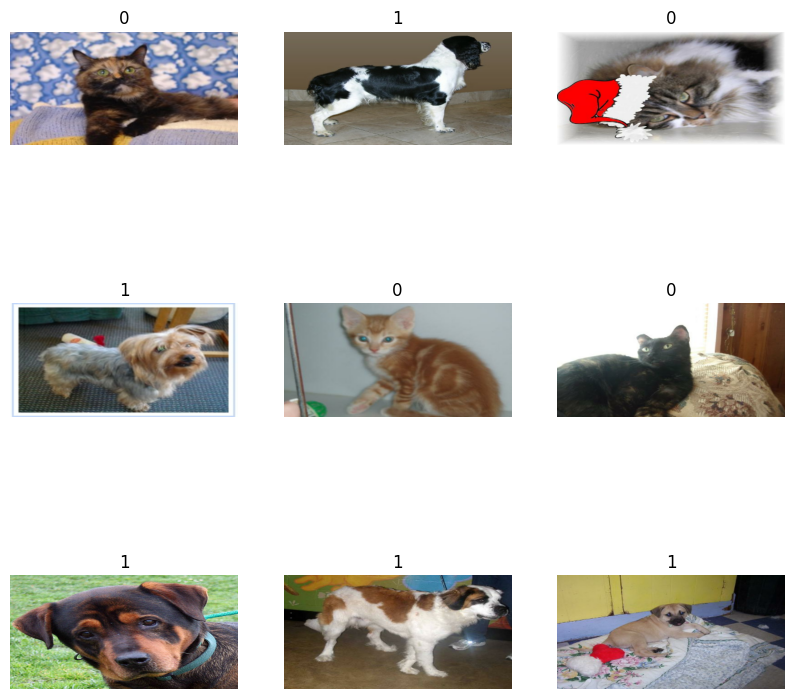

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Аугментация

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomBrightness(0.2)
    ]
)

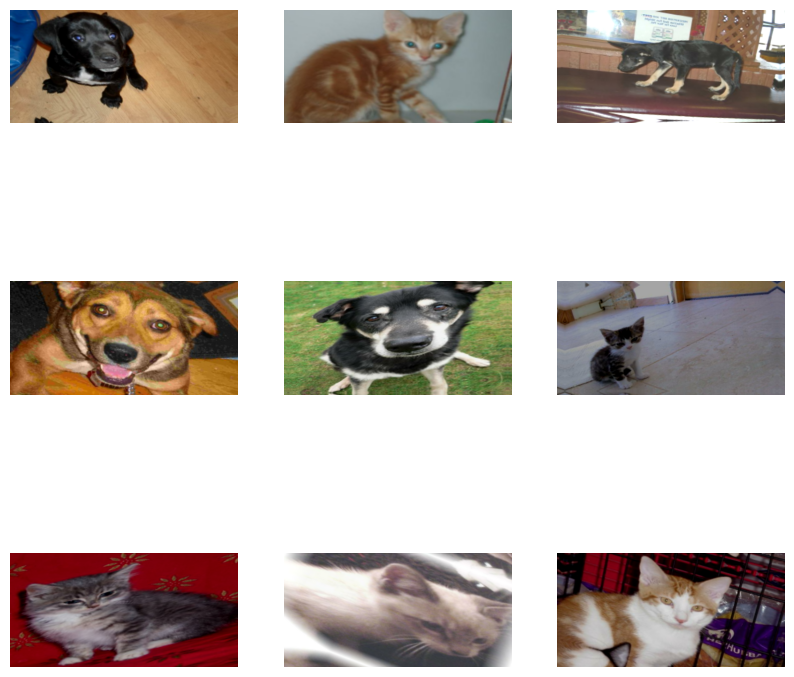

In [5]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

Сборка CNN с помощью TensorFlow и решение задачи классификации кошек и собак.

In [6]:
inputs = tf.keras.Input(shape=(200, 400, 3))

x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)

x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)

outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

In [7]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 400, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 200, 400, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 200, 400, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 100, 200, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 200, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 50, 100, 64)       0         
 g2D)                                                        

In [8]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

In [9]:
model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
50/50 [==============================] - 28s 556ms/step - loss: 0.9043 - accuracy: 0.5063 - val_loss: 0.6906 - val_accuracy: 0.5150
Epoch 2/10
50/50 [==============================] - 27s 547ms/step - loss: 0.6642 - accuracy: 0.6131 - val_loss: 0.6768 - val_accuracy: 0.6175
Epoch 3/10
50/50 [==============================] - 27s 548ms/step - loss: 0.5824 - accuracy: 0.7044 - val_loss: 0.6575 - val_accuracy: 0.6325
Epoch 4/10
50/50 [==============================] - 27s 546ms/step - loss: 0.4916 - accuracy: 0.7606 - val_loss: 0.6708 - val_accuracy: 0.6650
Epoch 5/10
50/50 [==============================] - 28s 552ms/step - loss: 0.3803 - accuracy: 0.8369 - val_loss: 0.8326 - val_accuracy: 0.6475
Epoch 6/10
50/50 [==============================] - 28s 561ms/step - loss: 0.2356 - accuracy: 0.8994 - val_loss: 0.8588 - val_accuracy: 0.6550
Epoch 7/10
50/50 [==============================] - 28s 565ms/step - loss: 0.1464 - accuracy: 0.9506 - val_loss: 1.2989 - val_accuracy: 0.6725

In [14]:
model.save("../models/cats_and_dogs_cnn.keras")

Протестируем

![Котики](../data/cats_and_dogs/cats/0.jpg)

In [16]:
img = tf.keras.preprocessing.image.load_img(
    "../data/cats_and_dogs/cats/0.jpg", target_size=(200, 400)
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)       

predictions = model.predict(img_array)
predictions

1/1 [==============================] - 0s 16ms/step


array([[0.9989618, 0.0010382]], dtype=float32)

Модель верно распозанает даже нечеткие изображения - хайп!⚡️

#### Вывод
1. **Вопрос**: Какие этапы предварительной обработки данных Вы выполняете и что происходит с данными?

    **Ответ**: Загрузка данных, их разделение на train и test, аугментация - создание копии исходного датасета, но в новом картинки будут повернуты, отзеркалены, приближены и с измененной яркостью.

2. **Вопрос**: Что означают параметры, которые Вы задаете? Какие слои есть в Вашей реализации CNN и что происходит на каждом слое?

    **Ответ**:

    `inputs = tf.keras.Input(shape=(200, 400, 3))` - картинка размера 200 * 400 c 3-мя цветами 

    `x = Conv2D(32, 3, padding="same", activation="relu")(x)` - в двумерном сверточном слое создается 32 ядра с размерами (3, 3), которые обучаются для нахождения закономерностей, `padding` гарантирует, что выходная картинка будет такого же размера как входная, функция активации отсекает ненужные признаки, чем вносит нелинейность

    `x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)` - сканирует полученные карты признаков окошком размера 2x2 пикселя с шагом `strides`=2 пикселя

    `x = tf.keras.layers.Flatten()(x)` - превращает многомерную матрицу признаков в одномерный вектор

    `x = tf.keras.layers.Dense(64, activation="relu")(x)` - полносвязный слой, который занимается анализом

    `outputs = tf.keras.layers.Dense(2, activation="softmax")(x)` - финальный слой, который формулирует окончательное решение. `softmax` превращает ответ в вероятности, по которым можно определить класс, к которому относится картинка

    `model = tf.keras.Model(inputs, outputs)` - объединяем все созданные слои в один объект

### Перенос обучения (Transfer Learning) методом тонкой настройки (Fine-Tuning)